# Linear algebra Homework assignment 3

In [11]:
import numpy as np
import math as m
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation  # Ensure FuncAnimation is imported


## Problem 1 - 4

In [12]:
# [TODO]
def compute_lookat(azim: float, elev: float):
    """
        Compute the look at vector. (Definition in Figure 3)
        azim: float, degree in [-180, 180],
        elev: float, degree in [-180, 180]
    """

    # For the definition of azim and elev, check
    # https://matplotlib.org/stable/api/toolkits/mplot3d/view_angles.html

       # Convert angles from degrees to radians
    a = np.radians(azim)
    b = np.radians(elev)

    # Compute lookat vector using spherical coordinates
    lookat = np.array([
        np.cos(b) * np.cos(a),  # x component
        np.cos(b) * np.sin(a),  # y component
        np.sin(b)               # z component
    ])

    # Normalize the lookat vector
    lookat /= np.linalg.norm(lookat)

    return lookat

In [13]:
# [TODO]
def compute_normal(P1: tuple, P2: tuple, P3: tuple):
    """
        Compute the normal vector, given P1, P2, P3 in counter-clockwise order.
    """

    # Compute vectors representing edges of the triangle
    v1 = np.array(P2) - np.array(P1)
    v2 = np.array(P3) - np.array(P1)

    # Compute the cross product of the edges to get the normal vector
    normal = np.cross(v1, v2)

    # Normalize the normal vector
    normal /= np.linalg.norm(normal)

    return normal

In [14]:
# [TODO]
def visible(face_normal: np.ndarray, lookat: np.ndarray):
    """
        Given a normal vector of a face, determine if the face (outward-facing side) is visible
    """

    # use the normal vector of the triangle and the lookat direction
    # to determine the visibility.

    # Compute the dot product of the face normal and the lookat vector
    dot_product = np.dot(face_normal, lookat)

    # A face is visible if the dot product is negative
    return dot_product < 0

In [15]:
# [TODO] compute cos(β) in Figure3
def compute_intensity(face_normal: np.ndarray, lookat: np.ndarray, lightsource: np.ndarray):
    """
        Given normal vector of a face (face_normal), viewing vector (lookat) and lightsource (lightsource),
        compute the specular intensity.
    """
    # Normalize all input vectors to ensure they are unit vectors
    face_normal = face_normal / np.linalg.norm(face_normal)
    lookat = lookat / np.linalg.norm(lookat)
    lightsource = lightsource / np.linalg.norm(lightsource)

    # Compute the reflection vector: R = 2 * (L . N) * N - L
    dot_ln = np.dot(lightsource, face_normal)  # Dot product of L and N
    reflect = 2 * dot_ln * face_normal - lightsource  # Reflection vector (R)

    # Compute the specular intensity: cos(β) = R . V
    intensity = np.dot(reflect, lookat)

    # Clamp intensity to the range [0, 1]
    intensity = max(0, intensity)

    return intensity

## Problem 5
Perform at least two tasks from the following list, and describe what you have done

- Change a model (please choose a convex object).
- Give each face of the model a different color.
- Change the movemnt of the light source.
- Other interesting changes

what i did:

Model Centering and Scaling: The convex icosahedron is centered at the origin and scaled for better visualization.

Face Shading: Each face’s color dynamically changes based on light intensity, giving the appearance of a different color per face.

Light Source Movement: The light source moves around the object in a circular trajectory, creating dynamic shading.

Enhanced Visualization: Edge highlighting, fixed camera view, and smooth shading enhance the overall visual appeal.

In [16]:
def read_obj_file(file_path):
    vertices = []
    faces = []

    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('v '):
                vertex = list(map(float, line.strip().split()[1:]))
                vertices.append(vertex)
            elif line.startswith('f '):
                face = [int(index.split('/')[0]) for index in line.strip().split()[1:]]
                faces.append(face)

    return np.array(vertices), np.array(faces)

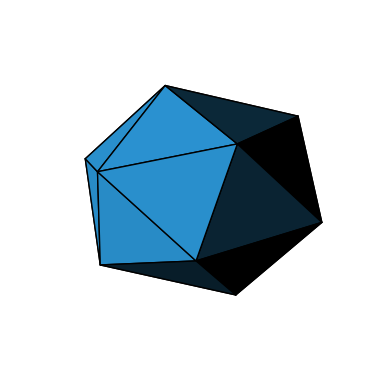

In [17]:
# The code below is just some hint for you. Feel free to modify anything if you want!

# Read .obj file
obj_file_path = 'icosahedron_modified.obj'  # Replace with your file path
vertices, faces = read_obj_file(obj_file_path)

# Modify the model: Center and scale it
center = np.mean(vertices, axis=0)
vertices = vertices - center  # Centering the model
vertices *= 1.5  # Scale uniformly

# Constants for the light source and animation
light_radius = 3.0  # Radius of the light's circular path
num_frames = 60  # Number of frames for the animation
base_color = np.array([0.2, 0.7, 1.0])  # Base color for faces

# Calculate bounds for plotting
max_x = np.max(vertices[:, 0])
min_x = np.min(vertices[:, 0])
max_y = np.max(vertices[:, 1])
min_y = np.min(vertices[:, 1])
max_z = np.max(vertices[:, 2])
min_z = np.min(vertices[:, 2])

# Create figure and 3D axis
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_axis_off()

# Function to update frames for animation
def update(frame):
    ax.clear()
    ax.set_axis_off()
    ax.set_xlim(min_x, max_x), ax.set_ylim(min_y, max_y), ax.set_zlim(min_z, max_z)
    ax.view_init(azim=60, elev=30)

    # Calculate light source position
    phi = 2 * np.pi * frame / num_frames
    light_dir = np.array([
        light_radius * np.cos(phi),  # X-coordinate
        light_radius * np.sin(phi),  # Y-coordinate
        2.0  # Fixed Z-coordinate
    ])
    light_dir /= np.linalg.norm(light_dir)  # Normalize light direction

    # Plot faces with lighting effect
    for face in faces:
        face_vertices = vertices[face - 1]  # Adjust for 1-based indexing in .obj
        face_normal = np.cross(
            face_vertices[1] - face_vertices[0],
            face_vertices[2] - face_vertices[0]
        )
        face_normal /= np.linalg.norm(face_normal)

        # Calculate intensity
        intensity = max(0, np.dot(face_normal, light_dir))  # Diffuse lighting
        face_color = base_color * intensity  # Adjust color by intensity

        # Add the face to the plot
        ax.add_collection3d(Poly3DCollection([face_vertices], color=face_color, edgecolor='k'))

# Create animation
ani = FuncAnimation(fig, update, frames=num_frames, interval=100)

# Define the student ID for filenames
studentID = '112006265'

# Save the GIF
gif_name = f'HW3_{studentID}.gif'
ani.save(gif_name, writer='imagemagick')

# Save the final frame as PNG
png_name = f'HW3_{studentID}.png'
plt.savefig(png_name)

plt.show()

## Problem 6
There is a type of terms, called **vn** (vertex normal), in the obj file.
However, it record vn as each

Please look up the definition of vertex normal and implement it accordingly. The OBJ
file with the corrected vertex normals is icosahedron modified.obj.

In [18]:
from collections import defaultdict

def load_obj(file_path):
    vertices = []
    faces = []
    vertex_normals = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue

            values = line.split()
            if not values:
                continue

            if values[0] == 'v':
                vertices.append([float(x) for x in values[1:4]])
            elif values[0] == 'vn':
                vertex_normals.append([float(x) for x in values[1:4]])
            elif values[0] == 'f':
                vertex_indices = []
                normal_indices = []

                for vertex in values[1:]:
                    # deal with v//vn
                    if '//' in vertex:
                        v_idx, _, n_idx = vertex.split('/')
                        vertex_indices.append(int(v_idx) - 1)
                        normal_indices.append(int(n_idx) - 1)
                    # deal with v
                    else:
                        vertex_indices.append(int(vertex) - 1)

                faces.append(vertex_indices)

    return np.array(vertices), np.array(faces), np.array(vertex_normals)

In [19]:
# [TODO]
def compute_vertex_normals(vertices, faces):

    vertex_normals = np.zeros_like(vertices)
    ######## write you code below
    # Iterate over each face
    for face in faces:
        # Get vertices of the face
        v0, v1, v2 = vertices[face[0]], vertices[face[1]], vertices[face[2]]

        # Compute the face normal using the cross product
        face_normal = np.cross(v1 - v0, v2 - v0)
        face_normal /= np.linalg.norm(face_normal)  # Normalize the face normal

        # Add the face normal to each vertex normal of the face
        for vertex_idx in face:
            vertex_normals[vertex_idx] += face_normal

    # Normalize all vertex normals
    for i in range(len(vertex_normals)):
        vertex_normals[i] /= np.linalg.norm(vertex_normals[i])


    #########

    return vertex_normals

In [20]:
obj_path = "icosahedron_modified.obj"
vertices, faces, vn = load_obj(obj_path)
vertex_normals = compute_vertex_normals(vertices, faces)

print("vertex normal：")
for i, normal in enumerate(vertex_normals):
     print(f"v{i+1:02d} normal: [{normal[0]:.6f}, {normal[1]:.6f}, {normal[2]:.6f}]")

if (np.allclose(vertex_normals, vn)):
    print("PASS")
else :
    print("ERROR")

vertex normal：
v01 normal: [0.000000, -0.525731, 0.850651]
v02 normal: [0.850651, 0.000000, 0.525731]
v03 normal: [0.850651, 0.000000, -0.525731]
v04 normal: [-0.850651, 0.000000, -0.525731]
v05 normal: [-0.850651, 0.000000, 0.525731]
v06 normal: [-0.525731, 0.850651, -0.000000]
v07 normal: [0.525731, 0.850651, 0.000000]
v08 normal: [0.525731, -0.850651, -0.000000]
v09 normal: [-0.525731, -0.850651, 0.000000]
v10 normal: [0.000000, -0.525731, -0.850651]
v11 normal: [0.000000, 0.525731, -0.850651]
v12 normal: [-0.000000, 0.525731, 0.850651]
PASS
